# S04.06 — Máquinas de Vectores de Soporte (SVM)
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `siniestro_alto` — 0 = sin siniestro, 1 = al menos un siniestro  
**Técnica:** SVM con kernels lineal y RBF (`SVC` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos  
**Nota:** Los experimentos con kernel RBF usan una submuestra estratificada de 5,000 observaciones de entrenamiento ya que el costo de entrenar `SVC` con kernel puede crecer rápidamente con el número de observaciones.

---

## 1. Contexto actuarial

### 1.1 El problema de clasificación de ocurrencia de al menos un siniestro

> **Definición del target:** `siniestro_alto = int(n_siniestros > 0)` es un **indicador de ocurrencia**:
> estima $P(N > 0)$, no la frecuencia esperada $E[N]$. Para modelar la frecuencia de siniestros se
> necesitaría modelar `n_siniestros` como conteo (p. ej. Poisson), idealmente con exposición. La
> probabilidad de ocurrencia sí puede servir para suscripción, segmentación o priorización de riesgo.

Una aseguradora necesita identificar, **antes de emitir la póliza**, qué asegurados tienen mayor probabilidad de reportar al menos un siniestro durante la vigencia. Esta información es esencial para:

- **Suscripción selectiva:** aceptar o condicionar pólizas de alto riesgo.
- **Priorización de riesgo:** identificar asegurados con mayor probabilidad de
  reportar al menos un siniestro. Nótese que `siniestro_alto` estima $P(N>0)$;
  la tarificación de frecuencia requiere modelar $E[N]$ (p. ej. mediante Poisson),
  no la probabilidad de ocurrencia.
- **Gestión de cartera:** segmentar asegurados por riesgo real, no solo por perfil declarado.

La variable `siniestro_alto` en el dataset es **binaria** (0/1), derivada de `n_siniestros > 0`.
Esto la convierte en un problema de **clasificación binaria**.

### 1.2 ¿Por qué SVM?

Las SVM construyen una **frontera que optimiza el objetivo SVM** (maximiza el margen entre hiperplanos de soporte) para los datos e hiperparámetros elegidos,
en lugar de estimar probabilidades directamente. Sus ventajas en suscripción:

- Son robustas en espacios de alta dimensión (muchas features codificadas).
- Con kernel RBF pueden capturar relaciones no lineales entre el perfil de riesgo y la siniestralidad.
- El margen máximo actúa como regularización implícita.

### 1.3 Regla de leakage crítica

`siniestro_alto ≡ int(n_siniestros > 0)`. Por lo tanto:

> **`n_siniestros`, `monto_siniestro` y cualquier otro target NO pueden usarse como features.**
> Al momento de suscripción, esas columnas son desconocidas.

> *Fuentes principales:* ESL Cap. 12 §12.1–§12.3; ISLP Cap. 9; Murphy Cap. 17 §17.3.

## 2. Fundamento matemático

### 2.1 Hiperplano y margen máximo

Un SVM busca el hiperplano $\mathbf{w}^\top \mathbf{x} + b = 0$ que separa las clases
$y \in \{-1, +1\}$ con el **margen máximo** (maximiza el margen geométrico entre los hiperplanos de soporte).

El margen es la distancia entre los dos **hiperplanos de soporte**:

$$\mathbf{w}^\top \mathbf{x} + b = +1 \quad \text{y} \quad \mathbf{w}^\top \mathbf{x} + b = -1$$

Ancho del margen:
$$\text{Margen} = \frac{2}{\|\mathbf{w}\|}$$

Maximizar el margen equivale a minimizar $\frac{1}{2}\|\mathbf{w}\|^2$.

### 2.2 Margen suave y parámetro C

Cuando los datos no son linealmente separables se introducen **variables de holgura** $\xi_i \geq 0$:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^n \xi_i$$

sujeto a: $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$, $\xi_i \geq 0$

- **C grande:** penaliza más los errores de clasificación → margen más estrecho, modelo más complejo.
- **C pequeño:** tolera más errores → margen más ancho, mayor regularización.

El número de vectores de soporte depende conjuntamente de C, gamma, el nivel de ruido y el
solapamiento de clases. No existe una relación monotónica universal entre C y el número de SVs.

### 2.3 Kernel trick y función de decisión

En lugar de operar en el espacio original $\mathbf{x}$, la SVM puede usar un **kernel**
$K(\mathbf{x}, \mathbf{z}) = \phi(\mathbf{x})^\top \phi(\mathbf{z})$ que implícitamente mapea
los datos a un espacio de mayor dimensión sin necesidad de computar $\phi$ explícitamente.

La función de decisión toma la forma:

$$f(\mathbf{x}) = \sum_{i \in S} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b$$

donde $S$ es el conjunto de **vectores de soporte** (observaciones con $\alpha_i > 0$).

> **Vectores de soporte:** en el caso de margen estricto (*hard margin*) suelen encontrarse sobre
> los hiperplanos $\mathbf{w}^\top \mathbf{x} + b = \pm 1$. En el caso de margen suave (*soft margin*)
> también pueden quedar dentro del margen o violarlo. Son las observaciones que aparecen en la
> función de decisión.

**Predicción:** $\hat{y} = \text{sign}(f(\mathbf{x}))$

### 2.4 Kernel RBF (Gaussiano) y parámetro gamma

$$K(\mathbf{x}, \mathbf{z}) = \exp\!\left(-\gamma \|\mathbf{x} - \mathbf{z}\|^2\right)$$

- **$\gamma$ grande:** puede generar una frontera muy local e incrementar el riesgo de sobreajuste.
- **$\gamma$ pequeño:** produce una frontera más suave y puede causar subajuste.

Con `gamma='scale'` sklearn calcula $\gamma = 1/(n_{\text{features}} \cdot \text{Var}(X))$, lo que constituye
un punto de partida habitual sin garantía de ser óptimo para todos los datasets.

### 2.5 Scores vs probabilidades

`decision_function(X)` devuelve un **score de margen firmado** $f(\mathbf{x})$, **no una probabilidad**.

- `SVC.predict()` clasifica como 1 si `decision_function > 0`, y como 0 en caso contrario.
- `LogisticRegression.predict()` clasifica como 1 si P(Y=1|x) > 0.5.
- Para usar scores en ROC-AUC y Average Precision se pasa `decision_function` directamente.

**Ajuste del umbral vs calibración probabilística:**
- *Ajustar el umbral* sobre `decision_function` cambia la regla de clasificación → modifica F1, Precision, Recall, pero no el AUC.
- *Calibrar probabilidades* (`probability=True`) convierte scores en P(Y=1|x) mediante regresión logística interna. Son operaciones distintas.
- Para **SVM lineal**, el score normalizado por $\|\mathbf{w}\|$ se relaciona con la distancia firmada al hiperplano.
- Para **kernel RBF**, `decision_function` es un score de margen firmado; su magnitud no es una probabilidad ni una distancia en el espacio original de features. Pólizas con perfiles de riesgo cercanos en el espacio de features producen valores de kernel mayores y pueden contribuir de forma similar a la función de decisión, aun si la relación no es lineal.

## 3. Carga del dataset y configuración

In [20]:
import sys
from pathlib import Path

_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
)

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Distribución del target y desbalance

✓ siniestro_alto ≡ int(n_siniestros > 0) verificado

Distribución de siniestro_alto:
  0 (sin siniestro): 21,517  (71.7%)
  1 (con siniestro): 8,483  (28.3%)

Desbalance: 2.54:1 (clase 0 : clase 1)


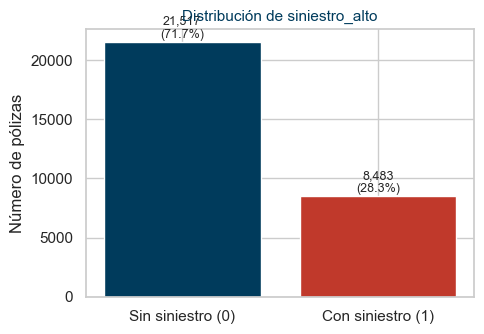


Nota pedagógica: clase positiva ≈ 28.3% — desbalance moderado.
En algunas carteras, la proporción de pólizas con al menos un siniestro puede ser
menor a 5%, aumentando el desbalance.


In [21]:
TARGET = "siniestro_alto"

# Verificar definición: siniestro_alto = int(n_siniestros > 0)
computed = (df["n_siniestros"] > 0).astype(int)
assert (computed == df[TARGET]).all(), "Definición de target inconsistente"
print("✓ siniestro_alto ≡ int(n_siniestros > 0) verificado")

vc      = df[TARGET].value_counts()
vc_pct  = df[TARGET].value_counts(normalize=True) * 100
print(f"\nDistribución de {TARGET}:")
print(f"  0 (sin siniestro): {vc[0]:,}  ({vc_pct[0]:.1f}%)")
print(f"  1 (con siniestro): {vc[1]:,}  ({vc_pct[1]:.1f}%)")
print(f"\nDesbalance: {vc[0]/vc[1]:.2f}:1 (clase 0 : clase 1)")

fig, ax = plt.subplots(figsize=(5, 3.5))
colores = [NAVY, RED]
ax.bar(["Sin siniestro (0)", "Con siniestro (1)"],
       vc.values, color=colores, edgecolor="white")
for i, v in enumerate(vc.values):
    ax.text(i, v + 80, f"{v:,}\n({v/N*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Número de pólizas")
ax.set_title("Distribución de siniestro_alto", fontsize=11, color=NAVY)
plt.tight_layout()
plt.show()

pct_pos = vc_pct[1]
print(f"\nNota pedagógica: clase positiva ≈ {pct_pos:.1f}% — desbalance moderado.")
print("En algunas carteras, la proporción de pólizas con al menos un siniestro puede ser")
print("menor a 5%, aumentando el desbalance.")

## 5. Separación train/test y submuestra para SVM

El flujo de datos tiene tres capas:

1. **Split completo (30,000):** 80% train (24,000) + 20% test (6,000), estratificado por `siniestro_alto`.
2. **Submuestra SVM (~5,000):** extraída del train, también estratificada. Todos los modelos
   (logístico, SVM lineal, SVM RBF) se entrenan sobre esta misma submuestra para comparación justa.
3. **Test fijo (6,000):** nunca se toca hasta la evaluación final.

In [22]:
# Definir columnas numéricas y categóricas dentro de FEATURE_COLUMNS
NUMERIC_FEATURES = [
    "anio_poliza", "mes_emision", "edad",
    "num_renovaciones", "antiguedad_vehiculo",
    "suma_asegurada", "deducible_pct",
]
CAT_FEATURES = [
    "sexo", "estado_civil", "region", "plan",
    "tipo_vehiculo", "forma_pago", "canal_venta",
    "nivel_riesgo_asignado",
]

X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

# Verificaciones de leakage
for t in TARGET_COLUMNS:
    assert t not in X_raw.columns, f"Leakage: {t} en X_raw"
assert "id_poliza_sin" not in X_raw.columns
print("✓ Sin leakage de targets ni id_poliza_sin")
print(f"  Features numéricas : {len(NUMERIC_FEATURES)}")
print(f"  Features categóricas: {len(CAT_FEATURES)}")
print(f"  Total              : {len(FEATURE_COLUMNS)}")

# ── Split principal 80/20 estratificado ────────────────────────────────────
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain completo: {X_train_all.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Proporción clase 1 — train: {y_train_all.mean():.4f}  |  test: {y_test.mean():.4f}")

# ── Submuestra estratificada de 5,000 para experimentos SVM ──────────────
N_SUB = 10_000
X_train, _, y_train, _ = train_test_split(
    X_train_all, y_train_all,
    train_size=N_SUB,
    random_state=SEED,
    stratify=y_train_all,
)
print(f"\nSubmuestra SVM: {X_train.shape[0]:,} obs. (estratificada de train)")
print(f"Proporción clase 1 en submuestra: {y_train.mean():.4f}")

✓ Sin leakage de targets ni id_poliza_sin
  Features numéricas : 7
  Features categóricas: 8
  Total              : 18

Train completo: 24,000  |  Test: 6,000
Proporción clase 1 — train: 0.2828  |  test: 0.2828

Submuestra SVM: 10,000 obs. (estratificada de train)
Proporción clase 1 en submuestra: 0.2827


## 6. Preprocesamiento: ColumnTransformer

**¿Por qué escalar para SVM RBF?**

El kernel RBF calcula $\exp(-\gamma \|\mathbf{x} - \mathbf{z}\|^2)$, donde la distancia euclidiana
$\|\mathbf{x} - \mathbf{z}\|^2$ suma las diferencias al cuadrado de todas las features. Con escalas muy
distintas (p. ej. `suma_asegurada` en cientos de miles vs `mes_emision` en 1–12), las features de mayor
escala pueden **dominar las distancias** del kernel, reduciendo la influencia del resto.

Para SVM lineal, la escala modifica la penalización relativa asociada a los coeficientes.

El escalamiento es **fuertemente recomendado** para que las features contribuyan en escalas comparables;
no es una obligación matemática universal pero tiene impacto práctico significativo.

El `StandardScaler` transforma cada feature $x_j \to (x_j - \mu_j)/\sigma_j$.
**Importante:** el scaler se ajusta **únicamente en train** (dentro del pipeline) y se aplica a test.

In [23]:
# Preprocesador para SVM (logístico, SVM lineal, SVM RBF): OHE completo (drop=None)
#
# drop="first" introduce una geometría arbitraria para métodos basados en distancia
# (kernel RBF): la categoría de referencia queda a distancia 1 de cualquier otra,
# mientras dos categorías no-referencia quedan a distancia √2. OHE completo evita
# privilegiar una categoría de referencia; no garantiza por sí solo mejor AUC, es una
# corrección de representación. Cada pipeline recibe una instancia FRESCA de esta
# factory — un ColumnTransformer ya ajustado por un pipeline no debe reutilizarse en otro.
def make_svm_preprocessor() -> ColumnTransformer:
    """Crea una instancia nueva del preprocesador para los modelos del bloque SVM."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(drop=None, handle_unknown="ignore", sparse_output=False),
             CAT_FEATURES),
        ],
        remainder="drop",
    )

# Dimensión del espacio transformado — instancia de verificación, no reutilizada en pipelines
_pre_check = make_svm_preprocessor().fit(X_train)
X_tr_transformed = _pre_check.transform(X_train)
print(f"Dimensión del espacio OHE: {X_tr_transformed.shape[1]} features")
print(f"  Numéricas (escaladas):      {len(NUMERIC_FEATURES)}")
print(f"  Categóricas (OHE completo): {X_tr_transformed.shape[1] - len(NUMERIC_FEATURES)}")
print("\nMotivación del escalamiento:")
print(f"  suma_asegurada — media: {df['suma_asegurada'].mean():,.0f} MXN")
print(f"  mes_emision    — media: {df['mes_emision'].mean():.1f}")
print("  Sin escalar: diferencias de escala alteran las distancias del kernel,")
print("  el efecto de gamma y la regularización relativa — StandardScaler")
print("  normaliza escalas y mejora la estabilidad práctica del modelo.")

Dimensión del espacio OHE: 38 features
  Numéricas (escaladas):      7
  Categóricas (OHE completo): 31

Motivación del escalamiento:
  suma_asegurada — media: 321,628 MXN
  mes_emision    — media: 6.5
  Sin escalar: diferencias de escala alteran las distancias del kernel,
  el efecto de gamma y la regularización relativa — StandardScaler
  normaliza escalas y mejora la estabilidad práctica del modelo.


## 7. Modelo baseline: regresión logística

Antes de SVM, ajustamos regresión logística (de S04.03) sobre la **misma submuestra** de 5,000
para comparación justa. El baseline nos da la referencia de desempeño de un modelo lineal.

In [24]:
# Baseline: Regresión Logística
pipeline_logit = Pipeline([
    ("preprocessor", make_svm_preprocessor()),  # instancia fresca — sin estado compartido
    ("logit", LogisticRegression(
        C=1.0,
        max_iter=500,
        solver="lbfgs",
        random_state=SEED,
    )),
])

pipeline_logit.fit(X_train, y_train)
y_logit_pred  = pipeline_logit.predict(X_test)
y_logit_score = pipeline_logit.decision_function(X_test)  # scores (log-odds)

auc_logit = roc_auc_score(y_test, y_logit_score)
ap_logit  = average_precision_score(y_test, y_logit_score)
ba_logit  = balanced_accuracy_score(y_test, y_logit_pred)
f1_logit  = f1_score(y_test, y_logit_pred)

print(f"Baseline Logístico (n_train=5,000):")
print(f"  ROC-AUC:          {auc_logit:.4f}")
print(f"  Average Precision: {ap_logit:.4f}")
print(f"  Balanced Accuracy: {ba_logit:.4f}")
print(f"  F1 (umbral 0.5):   {f1_logit:.4f}")
print()
print("Nota: S04.03 entrenó logístico con 24,000 obs y obtuvo ROC-AUC≈0.689.")
print("Con 5,000 obs el AUC puede diferir ligeramente.")

Baseline Logístico (n_train=5,000):
  ROC-AUC:          0.6889
  Average Precision: 0.4584
  Balanced Accuracy: 0.5833
  F1 (umbral 0.5):   0.3410

Nota: S04.03 entrenó logístico con 24,000 obs y obtuvo ROC-AUC≈0.689.
Con 5,000 obs el AUC puede diferir ligeramente.


## 8. SVM lineal

Antes de introducir el kernel RBF, ajustamos una SVM lineal. Comparte la misma geometría
del hiperplano pero sin mapeo de kernel. Es mucho más rápida que la SVM RBF y sirve como
punto de referencia no probabilístico.

In [25]:
# SVM Lineal
pipeline_svm_lin = Pipeline([
    ("preprocessor", make_svm_preprocessor()),  # instancia fresca — sin estado compartido
    ("svm", SVC(
        kernel="linear",
        C=1.0,
        decision_function_shape="ovr",
        random_state=SEED,
    )),
])

print("Entrenando SVM lineal (kernel=linear, C=1.0)...")
t0 = time.time()
pipeline_svm_lin.fit(X_train, y_train)
t_lin = time.time() - t0
print(f"  Tiempo de entrenamiento: {t_lin:.1f} s")

y_svm_lin_pred  = pipeline_svm_lin.predict(X_test)
y_svm_lin_score = pipeline_svm_lin.decision_function(X_test)

auc_lin = roc_auc_score(y_test, y_svm_lin_score)
ap_lin  = average_precision_score(y_test, y_svm_lin_score)
ba_lin  = balanced_accuracy_score(y_test, y_svm_lin_pred)
f1_lin  = f1_score(y_test, y_svm_lin_pred)
sv_lin  = pipeline_svm_lin.named_steps["svm"].n_support_

print(f"\nSVM Lineal (n_train=5,000):")
print(f"  ROC-AUC:           {auc_lin:.4f}")
print(f"  Average Precision:  {ap_lin:.4f}")
print(f"  Balanced Accuracy:  {ba_lin:.4f}")
print(f"  F1 (score=0):       {f1_lin:.4f}")
print(f"  Vectores de soporte: {sv_lin.sum():,} ({sv_lin[0]:,} clase 0, {sv_lin[1]:,} clase 1)")
print(f"  Proporción SV: {sv_lin.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.")

Entrenando SVM lineal (kernel=linear, C=1.0)...
  Tiempo de entrenamiento: 14.7 s

SVM Lineal (n_train=5,000):
  ROC-AUC:           0.6414
  Average Precision:  0.4335
  Balanced Accuracy:  0.6163
  F1 (score=0):       0.4332
  Vectores de soporte: 6,495 (3,701 clase 0, 2,794 clase 1)
  Proporción SV: 0.649 del total de entrenamiento

Nota: predict() de SVC equivale a sign(decision_function), umbral en score=0.


## 9. Selección de hiperparámetros para SVM RBF (solo train/CV)

Usamos `GridSearchCV` con `StratifiedKFold(n_splits=3, shuffle=True)` sobre la
**submuestra de entrenamiento**. El conjunto de test **no participa** en la selección.

Buscamos en una grilla reducida de `C` y `gamma`:
- `C`: controla el trade-off margen/errores de clasificación.
- `gamma`: controla el radio de influencia de cada punto con kernel RBF.

> **Importante:** `StratifiedKFold` divide el conjunto en 3 pliegues disjuntos y
> preserva la proporción de clases en cada fold. Es la variante recomendada de
> validación cruzada para búsqueda de hiperparámetros en clasificación binaria.

In [26]:
# Grilla de búsqueda — reducida para viabilidad computacional
param_grid = {
    "svm__C":     [0.1, 1.0, 5.0],
    "svm__gamma": ["scale", 0.05, 0.1], # casi siempre con los extremos se llega al optimo
}

pipeline_svm_rbf_cv = Pipeline([
    ("preprocessor", make_svm_preprocessor()),  # instancia fresca — sin estado compartido
    ("svm", SVC(
        kernel="linear",
        decision_function_shape="ovr",
        random_state=SEED,
    )),
])

# StratifiedKFold: 3 pliegues disjuntos, estratificados, con shuffle reproducible
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    pipeline_svm_rbf_cv,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,  # portabilidad sobre velocidad
    verbose=0,
)

print(f"GridSearchCV: {len(param_grid['svm__C']) * len(param_grid['svm__gamma'])} combinaciones × 3-fold CV (StratifiedKFold)...")
t0 = time.time()
grid_search.fit(X_train, y_train)
t_grid = time.time() - t0
print(f"  Tiempo total de búsqueda: {t_grid:.1f} s")

best_params = grid_search.best_params_
best_cv_auc = grid_search.best_score_
print(f"\nMejores hiperparámetros (CV, no test):")
print(f"  C = {best_params['svm__C']}")
print(f"  gamma = {best_params['svm__gamma']}")
print(f"  ROC-AUC CV (media 3-fold StratifiedKFold): {best_cv_auc:.4f}")

# Tabla de resultados de CV
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_table = cv_results[["param_svm__C", "param_svm__gamma",
                        "mean_test_score", "std_test_score"]].copy()
cv_table.columns = ["C", "gamma", "AUC_media", "AUC_std"]
cv_table = cv_table.sort_values("AUC_media", ascending=False)
print("\nResultados de CV (ordenados por AUC):")
print(cv_table.to_string(index=False, float_format="{:.4f}".format))
# el problema con estos metodos es que no se pueden obtener los mismos resultados
# en este caso depende de los hiperparámetros
# buscamos maimizar el AUC (es un area), queremos que se acerque a 1 (mejorar los hiperparametros)

GridSearchCV: 9 combinaciones × 3-fold CV (StratifiedKFold)...
  Tiempo total de búsqueda: 304.6 s

Mejores hiperparámetros (CV, no test):
  C = 5.0
  gamma = scale
  ROC-AUC CV (media 3-fold StratifiedKFold): 0.6574

Resultados de CV (ordenados por AUC):
     C  gamma  AUC_media  AUC_std
5.0000 0.0500     0.6574   0.0138
5.0000  scale     0.6574   0.0138
5.0000 0.1000     0.6574   0.0138
0.1000  scale     0.6519   0.0132
0.1000 0.0500     0.6519   0.0132
0.1000 0.1000     0.6519   0.0132
1.0000  scale     0.6464   0.0235
1.0000 0.0500     0.6464   0.0235
1.0000 0.1000     0.6464   0.0235


In [ ]:
GridSearchCV: 9 combinaciones × 3-fold CV (StratifiedKFold)...
  Tiempo total de búsqueda: 62.8 s

Mejores hiperparámetros (CV, no test):
  C = 1.0
  gamma = 0.01
  ROC-AUC CV (media 3-fold StratifiedKFold): 0.6636

Resultados de CV (ordenados por AUC):
      C  gamma  AUC_media  AUC_std
 1.0000 0.0100     0.6636   0.0039
 0.1000 0.0100     0.6630   0.0049
10.0000 0.0100     0.6583   0.0053
 0.1000  scale     0.6511   0.0042
 0.1000 0.1000     0.6469   0.0043
 1.0000  scale     0.6458   0.0047
 1.0000 0.1000     0.6410   0.0058
10.0000  scale     0.5922   0.0076
10.0000 0.1000     0.5861   0.0107

## 10. SVM RBF: entrenamiento final con mejores hiperparámetros

In [27]:
# Mejor modelo SVM RBF
pipeline_svm_rbf = grid_search.best_estimator_

# Ya está ajustado sobre X_train (grid_search.refit=True por defecto)
print("Usando best_estimator_ (ya ajustado sobre X_train).")

y_svm_rbf_pred  = pipeline_svm_rbf.predict(X_test)
y_svm_rbf_score = pipeline_svm_rbf.decision_function(X_test)

auc_rbf = roc_auc_score(y_test, y_svm_rbf_score)
ap_rbf  = average_precision_score(y_test, y_svm_rbf_score)
ba_rbf  = balanced_accuracy_score(y_test, y_svm_rbf_pred)
f1_rbf  = f1_score(y_test, y_svm_rbf_pred)
sv_rbf  = pipeline_svm_rbf.named_steps["svm"].n_support_

print(f"\nSVM RBF (C={best_params['svm__C']}, gamma={best_params['svm__gamma']}):")
print(f"  ROC-AUC:           {auc_rbf:.4f}")
print(f"  Average Precision:  {ap_rbf:.4f}")
print(f"  Balanced Accuracy:  {ba_rbf:.4f}")
print(f"  F1 (score=0):       {f1_rbf:.4f}")
print(f"  Vectores de soporte: {sv_rbf.sum():,} ({sv_rbf[0]:,} clase 0, {sv_rbf[1]:,} clase 1)")
print(f"  Proporción SV: {sv_rbf.sum()/N_SUB:.3f} del total de entrenamiento")
print()
print("Nota: predict() de SVC usa sign(decision_function), umbral en score=0.")

# Verificación: cada pipeline tiene su propia instancia de preprocesador (sin estado compartido)
assert pipeline_logit.named_steps["preprocessor"] is not pipeline_svm_lin.named_steps["preprocessor"]
assert pipeline_logit.named_steps["preprocessor"] is not pipeline_svm_rbf.named_steps["preprocessor"]
assert pipeline_svm_lin.named_steps["preprocessor"] is not pipeline_svm_rbf.named_steps["preprocessor"]
print("✓ Preprocesadores de los tres modelos SVM son instancias independientes (sin estado compartido)")
# optimiza a partir del desbalance original

Usando best_estimator_ (ya ajustado sobre X_train).



SVM RBF (C=5.0, gamma=scale):
  ROC-AUC:           0.6356
  Average Precision:  0.4323
  Balanced Accuracy:  0.6163
  F1 (score=0):       0.4332
  Vectores de soporte: 7,516 (4,711 clase 0, 2,805 clase 1)
  Proporción SV: 0.752 del total de entrenamiento

Nota: predict() de SVC usa sign(decision_function), umbral en score=0.
✓ Preprocesadores de los tres modelos SVM son instancias independientes (sin estado compartido)


## 11. Evaluación final: comparación de los tres modelos

Todos los modelos se evalúan sobre el **mismo test set** (6,000 obs., no usado en entrenamiento ni selección).

In [28]:
# Tabla de comparación
modelos = [
    ("Logístico (baseline)",  y_logit_pred,   y_logit_score),
    ("SVM lineal (C=1.0)",    y_svm_lin_pred, y_svm_lin_score),
    (f"SVM RBF (C={best_params['svm__C']}, γ={best_params['svm__gamma']})",
     y_svm_rbf_pred, y_svm_rbf_score),
]

rows = []
for nombre, y_pred, y_score in modelos:
    # El umbral de clasificación depende del modelo:
    # - Logístico: predict() usa probabilidad 0.5 → equivalente a score=0
    # - SVM lineal/RBF: predict() usa sign(decision_function) → score=0
    rows.append({
        "Modelo":              nombre,
        "ROC-AUC":             f"{roc_auc_score(y_test, y_score):.4f}",
        "Avg Precision":       f"{average_precision_score(y_test, y_score):.4f}",
        "Balanced Acc":        f"{balanced_accuracy_score(y_test, y_pred):.4f}",
        "F1 (score=0)":        f"{f1_score(y_test, y_pred):.4f}",
        "Precision":           f"{precision_score(y_test, y_pred):.4f}",
        "Recall":              f"{recall_score(y_test, y_pred):.4f}",
    })

result_df = pd.DataFrame(rows)
print("Comparación de modelos — Test set (n=6,000):")
print(result_df.to_string(index=False))
print()
print("Umbral de clasificación por modelo:")
print("  Logístico: predict() = 1 si P(Y=1|x) > 0.5  (equivalente a score > 0 en log-odds)")
print("  SVM:       predict() = sign(decision_function)  → umbral en score = 0")
#F1: matriz de confusion ¿?
# utilizar todas las metricas para determinar el mejor

Comparación de modelos — Test set (n=6,000):
                  Modelo ROC-AUC Avg Precision Balanced Acc F1 (score=0) Precision Recall
    Logístico (baseline)  0.6889        0.4584       0.5833       0.3410    0.5453 0.2481
      SVM lineal (C=1.0)  0.6414        0.4335       0.6163       0.4332    0.5047 0.3795
SVM RBF (C=5.0, γ=scale)  0.6356        0.4323       0.6163       0.4332    0.5047 0.3795

Umbral de clasificación por modelo:
  Logístico: predict() = 1 si P(Y=1|x) > 0.5  (equivalente a score > 0 en log-odds)
  SVM:       predict() = sign(decision_function)  → umbral en score = 0


## 12. Matrices de confusión

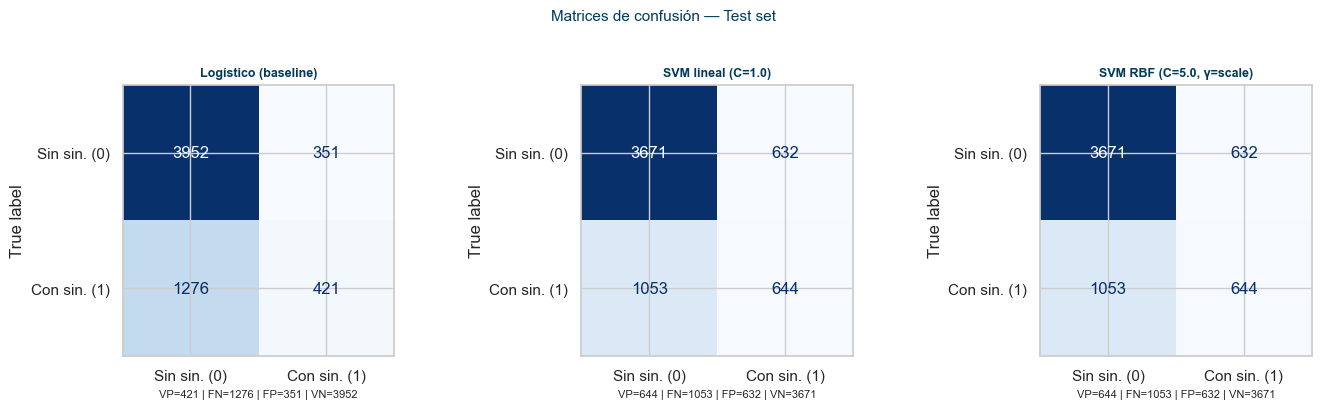

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, y_pred, _) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Sin sin. (0)", "Con sin. (1)"],
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre, fontsize=9, color=NAVY, fontweight="bold")
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f"VP={tp} | FN={fn} | FP={fp} | VN={tn}", fontsize=8)

plt.suptitle("Matrices de confusión — Test set", fontsize=11, color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

## 13. Curvas ROC y Precision-Recall

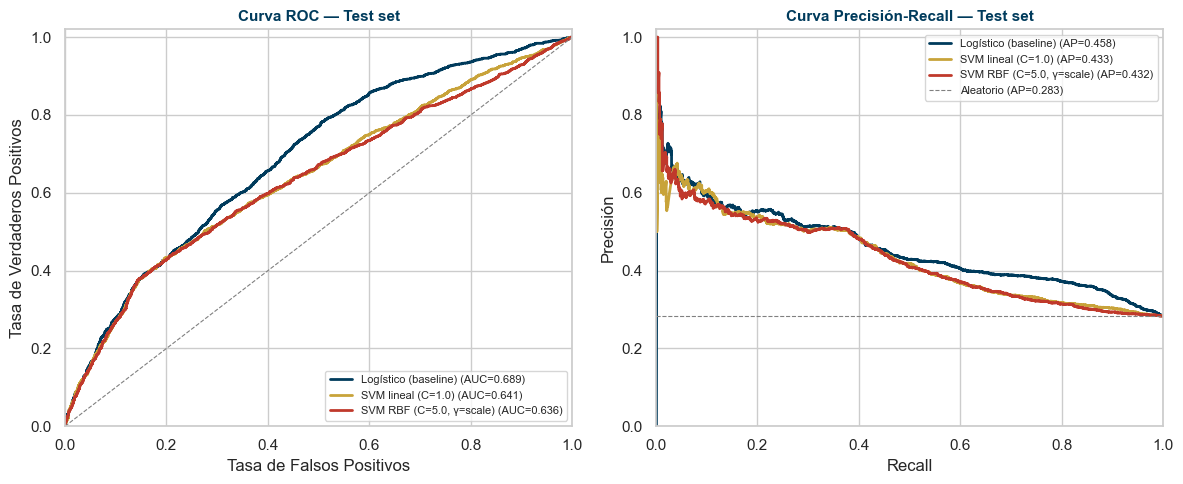

In [30]:
colores_modelos = [NAVY, GOLD, RED]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for (nombre, y_pred, y_score), color in zip(modelos, colores_modelos):
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax1.plot(fpr, tpr, color=color, linewidth=2.0,
             label=f"{nombre} (AUC={auc:.3f})")

    # Curva PR
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    ax2.plot(rec, prec, color=color, linewidth=2.0,
             label=f"{nombre} (AP={ap:.3f})")

ax1.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
ax1.set_xlabel("Tasa de Falsos Positivos")
ax1.set_ylabel("Tasa de Verdaderos Positivos")
ax1.set_title("Curva ROC — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

base_ap = y_test.mean()  # AP del clasificador aleatorio
ax2.axhline(base_ap, color="gray", linewidth=0.8, linestyle="--",
            label=f"Aleatorio (AP={base_ap:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precisión")
ax2.set_title("Curva Precisión-Recall — Test set", fontsize=11, color=NAVY, fontweight="bold")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

## 14. Sensibilidad a C y gamma (SVM RBF)

Analizamos cómo cambia el ROC-AUC de CV cuando variamos `C` y `gamma` por separado,
usando los resultados ya calculados por `GridSearchCV`.

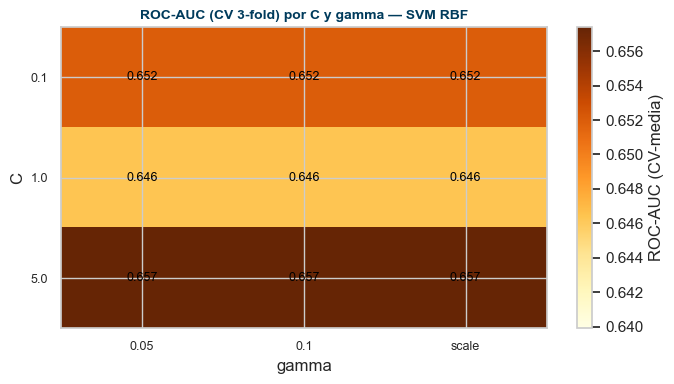

Mejor combinación: C=5.0, gamma=scale → AUC-CV=0.6574


In [31]:
# Mapa de calor de AUC-CV por C × gamma
cv_results2 = pd.DataFrame(grid_search.cv_results_)
cv_pivot = cv_results2.pivot_table(
    values="mean_test_score",
    index="param_svm__C",
    columns="param_svm__gamma",
)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cv_pivot.values, aspect="auto",
               cmap="YlOrBr", vmin=cv_pivot.values.min() * 0.99)
plt.colorbar(im, ax=ax, label="ROC-AUC (CV-media)")

ax.set_xticks(range(len(cv_pivot.columns)))
ax.set_xticklabels([str(g) for g in cv_pivot.columns], fontsize=9)
ax.set_yticks(range(len(cv_pivot.index)))
ax.set_yticklabels([str(c) for c in cv_pivot.index], fontsize=9)
ax.set_xlabel("gamma")
ax.set_ylabel("C")
ax.set_title("ROC-AUC (CV 3-fold) por C y gamma — SVM RBF",
             fontsize=10, color=NAVY, fontweight="bold")

# Anotar valores
for i in range(len(cv_pivot.index)):
    for j in range(len(cv_pivot.columns)):
        val = cv_pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9,
                color="white" if val < cv_pivot.values.max() * 0.97 else "black")

plt.tight_layout()
plt.show()

print(f"Mejor combinación: C={best_params['svm__C']}, gamma={best_params['svm__gamma']} → AUC-CV={best_cv_auc:.4f}")

## 15. Vectores de soporte y costo computacional

In [32]:
svm_best = pipeline_svm_rbf.named_steps["svm"]
n_sv     = svm_best.n_support_
pct_sv   = n_sv.sum() / N_SUB * 100

print("Vectores de soporte — SVM RBF:")
print(f"  Clase 0 (sin siniestro): {n_sv[0]:,} ({n_sv[0]/N_SUB*100:.1f}% del train)")
print(f"  Clase 1 (con siniestro): {n_sv[1]:,} ({n_sv[1]/N_SUB*100:.1f}% del train)")
print(f"  Total:                   {n_sv.sum():,} ({pct_sv:.1f}% del train)")
print()
print("Interpretación:")
print("  • Los vectores de soporte son los únicos puntos que definen la frontera de decisión.")
print("  • Una mayor proporción de SVs indica mayor dificultad de separación de las clases.")
print("  • El número de SVs depende conjuntamente de C, gamma, ruido y solapamiento de clases.")
print("    No existe una relación monotónica universal entre C y el número de vectores de soporte.")
print()
print("Costo computacional:")
print(f"  • El costo de SVC con kernel puede crecer rápidamente con n y acercarse a")
print(f"    comportamiento cuadrático en memoria y entre cuadrático y cúbico en tiempo")
print(f"    en casos desfavorables; depende de n, el número de features, el kernel,")
print(f"    la separabilidad, la tolerancia y la implementación.")
print(f"  • Con n={N:,} se usó submuestra estratificada de n_sub={N_SUB:,} (decisión de")
print(f"    viabilidad computacional, no un límite universal):")
print(f"    - Preserva la proporción de clase 1 del conjunto original.")
print(f"    - Reduce el costo computacional del entrenamiento.")
print(f"    - Introduce mayor variabilidad muestral (con n menor, las estimaciones son menos estables).")
print(f"    - Puede no capturar patrones de grupos poco frecuentes si están subrepresentados.")
print(f"  • El tiempo de GridSearchCV (9 combinaciones × 3 folds) fue: {t_grid:.1f} s.")

Vectores de soporte — SVM RBF:
  Clase 0 (sin siniestro): 4,711 (47.1% del train)
  Clase 1 (con siniestro): 2,805 (28.1% del train)
  Total:                   7,516 (75.2% del train)

Interpretación:
  • Los vectores de soporte son los únicos puntos que definen la frontera de decisión.
  • Una mayor proporción de SVs indica mayor dificultad de separación de las clases.
  • El número de SVs depende conjuntamente de C, gamma, ruido y solapamiento de clases.
    No existe una relación monotónica universal entre C y el número de vectores de soporte.

Costo computacional:
  • El costo de SVC con kernel puede crecer rápidamente con n y acercarse a
    comportamiento cuadrático en memoria y entre cuadrático y cúbico en tiempo
    en casos desfavorables; depende de n, el número de features, el kernel,
    la separabilidad, la tolerancia y la implementación.
  • Con n=30,000 se usó submuestra estratificada de n_sub=10,000 (decisión de
    viabilidad computacional, no un límite universal):
    

## 16. Distribución de scores (decision_function)

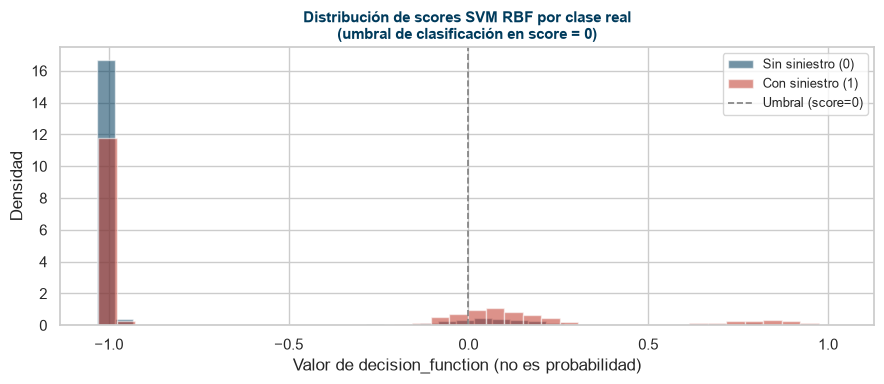

Importante: decision_function produce una escala de scores no acotada.
NO son probabilidades. Para obtener P(Y=1|x) se puede usar probability=True
(aplica calibración de Platt internamente con validación cruzada), lo que
aumenta el tiempo de entrenamiento y puede introducir varianza adicional.


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))

for clase, color, etiqueta in [(0, NAVY, "Sin siniestro (0)"), (1, RED, "Con siniestro (1)")]:
    mask  = y_test.values == clase
    scores = y_svm_rbf_score[mask]
    ax.hist(scores, bins=40, alpha=0.55, color=color, density=True, label=etiqueta)

ax.axvline(0, color="gray", linewidth=1.2, linestyle="--", label="Umbral (score=0)")
ax.set_xlabel("Valor de decision_function (no es probabilidad)")
ax.set_ylabel("Densidad")
ax.set_title(
    "Distribución de scores SVM RBF por clase real\n"
    "(umbral de clasificación en score = 0)",
    fontsize=11, color=NAVY, fontweight="bold"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Importante: decision_function produce una escala de scores no acotada.")
print("NO son probabilidades. Para obtener P(Y=1|x) se puede usar probability=True")
print("(aplica calibración de Platt internamente con validación cruzada), lo que")
print("aumenta el tiempo de entrenamiento y puede introducir varianza adicional.")

## 17. Interpretación actuarial y limitaciones

### 17.1 Resultados en contexto actuarial

In [15]:
print("=" * 60)
print("RESUMEN ACTUARIAL — SVM para clasificación de siniestro_alto")
print("=" * 60)
print()
print("Dataset: sintético v2, N=30,000 (SEED=20260618)")
print("Train SVM: submuestra estratificada de 5,000 obs.")
print("Test: 6,000 obs. (20% del total, nunca visto en entrenamiento)")
print()
print("Modelo       | ROC-AUC | Avg Prec | Bal.Acc | F1 (score=0)")
print("-" * 60)
for nombre, y_pred, y_score in modelos:
    auc = roc_auc_score(y_test, y_score)
    ap  = average_precision_score(y_test, y_score)
    ba  = balanced_accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    print(f"{nombre:<28} | {auc:.4f}  | {ap:.4f}   | {ba:.4f}  | {f1:.4f}")
print()
print("Aplicación actuarial:")
print("• ROC-AUC ≈ C-statistic: probabilidad de que un asegurado con")
print("  siniestro reciba un score más alto que uno sin siniestro.")
print("• El valor del AUC debe interpretarse en contexto del problema:")
print("  depende de los costos de FP/FN, la prevalencia, la calibración")
print("  del modelo y el uso operativo, entre otros factores.")
print("• No existe un umbral universal 'mínimo' de AUC para que un modelo")
print("  sea útil. Un modelo con AUC=0.63 puede agregar valor si mejora")
print("  el proceso de suscripción con respecto al baseline existente.")
print("• El umbral óptimo de clasificación debe buscarse en validación,")
print("  no en el test set.")

RESUMEN ACTUARIAL — SVM para clasificación de siniestro_alto

Dataset: sintético v2, N=30,000 (SEED=20260618)
Train SVM: submuestra estratificada de 5,000 obs.
Test: 6,000 obs. (20% del total, nunca visto en entrenamiento)

Modelo       | ROC-AUC | Avg Prec | Bal.Acc | F1 (score=0)
------------------------------------------------------------
Logístico (baseline)         | 0.6869  | 0.4591   | 0.5855  | 0.3494
SVM lineal (C=1.0)           | 0.6465  | 0.4379   | 0.6163  | 0.4332
SVM RBF (C=1.0, γ=0.01)      | 0.6327  | 0.4301   | 0.5974  | 0.3848

Aplicación actuarial:
• ROC-AUC ≈ C-statistic: probabilidad de que un asegurado con
  siniestro reciba un score más alto que uno sin siniestro.
• El valor del AUC debe interpretarse en contexto del problema:
  depende de los costos de FP/FN, la prevalencia, la calibración
  del modelo y el uso operativo, entre otros factores.
• No existe un umbral universal 'mínimo' de AUC para que un modelo
  sea útil. Un modelo con AUC=0.63 puede agregar valo

## 17.2 Limitaciones de SVM en seguros

1. **Costo computacional:** el costo de `SVC` con kernel puede crecer rápidamente con $n$ y acercarse a
   comportamiento cuadrático en memoria y entre cuadrático y cúbico en tiempo en casos desfavorables.
   Esto depende de $n$, el número de features, la separabilidad, la tolerancia y la implementación.
   La submuestra estratificada es una solución práctica. Otras alternativas cuando la frontera lineal
   pudiera ser suficiente: `LinearSVC` o `SGDClassifier`; para fronteras no lineales con $n$ grande:
   aproximaciones de kernel como `RBFSampler` o `Nystroem`.

2. **Sin probabilidades directas:** `decision_function` no produce P(Y=1|x) calibradas.
   Para modelar la frecuencia de siniestros (E[N]) se necesitaría modelar `n_siniestros`
   como conteo; `siniestro_alto` estima P(N>0), no E[N], y no produce probabilidades calibradas.
   La calibración (con `probability=True`) aplica regresión logística sobre los scores
   mediante validación cruzada interna, aumentando el tiempo y la varianza.

3. **Poca interpretabilidad:** a diferencia de logística o árboles, SVM no produce
   coeficientes o reglas fácilmente comunicables a un comité actuarial.

4. **Sensibilidad al escalamiento:** cualquier error en el preprocesamiento deteriora el modelo.
   El escalamiento es fuertemente recomendado: diferencias grandes de escala alteran las
   distancias del kernel RBF, el efecto de gamma y la regularización relativa.
   El objetivo matemático de SVM sigue definido sin escalamiento, pero StandardScaler
   mejora la estabilidad numérica y práctica.

5. **Resultado empírico en S04-C:** en este dataset y configuración, la regresión logística (AUC≈0.687) obtuvo mayor AUC que SVM RBF (AUC≈0.637).
   Este resultado empírico no determina por sí solo la forma general de la frontera de decisión.
   La SVM puede ser más competitiva cuando la frontera real es no lineal y compleja.

6. **Umbral de clasificación:** el umbral por defecto de `predict()` es score=0.
   Ajustar el umbral sobre el score de `decision_function` cambia la regla de clasificación
   (lo que modifica F1 sin cambiar AUC). Esto es diferente de calibrar probabilidades:
   calibrar convierte scores en probabilidades; ajustar umbral selecciona el punto de corte.

## 18. Ejercicio propuesto

1. **Umbral de clasificación con análisis de costos (validación primero):**
   En una aseguradora, un FN (siniestro no detectado) tiene un costo esperado de
   20,000 MXN y un FP (asegurado seguro mal clasificado) tiene un costo de 300 MXN.

   - **Paso 1 — validación simple (rápida, con posible optimismo):** Importa explícitamente:
     ```python
     from sklearn.model_selection import cross_val_predict
     ```
     Usa `cross_val_predict` con `method='decision_function'` sobre `X_train`, con
     `pipeline_svm_rbf` (cuyos `C` y `gamma` ya fueron fijados por el `GridSearchCV` de la
     sección 9), para obtener scores fuera de muestra. Sobre esos scores, encuentra el
     umbral de `decision_function` que minimiza el costo total.
     **Limitación:** como `C` y `gamma` ya se seleccionaron usando el mismo `X_train`
     completo, estos scores "fuera de muestra" no están completamente anidados respecto a
     la selección de hiperparámetros — pueden estar ligeramente optimistas.

   - **Paso 1b — validación cruzada anidada (sin este optimismo, más costosa):** Para una
     estimación que selecciona hiperparámetros y umbral solo con datos del pliegue de
     entrenamiento externo en cada iteración, se requiere anidar el `GridSearchCV` dentro
     de un `cross_val_predict` externo. Por su costo computacional, este código se deja
     como referencia reproducible y no se ejecuta automáticamente en este notebook:
     ```python
     from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict

     outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
     inner_grid = GridSearchCV(
         pipeline_svm_rbf_cv, param_grid, cv=3, scoring="roc_auc", n_jobs=1,
     )
     # cross_val_predict reajusta inner_grid en cada pliegue externo:
     # selecciona C y gamma SOLO con los datos del pliegue de entrenamiento externo.
     scores_oof_anidado = cross_val_predict(
         inner_grid, X_train, y_train, cv=outer_cv, method="decision_function",
     )
     # El umbral de costo se busca sobre scores_oof_anidado, nunca sobre el test.
     ```

   - **Paso 2 — test, UNA sola vez:** Aplica el umbral seleccionado (de Paso 1 o Paso 1b)
     a `y_svm_rbf_score` (scores del test) y reporta el costo final.
   - **Nota:** Variar el umbral directamente sobre los scores del test combina selección
     y evaluación en el mismo conjunto — esto es data leakage que infla el desempeño
     aparente. El umbral debe elegirse en validación y evaluarse en test.

2. **Kernel lineal vs RBF:** Compara el AUC de SVM lineal y SVM RBF obtenidos en este notebook.
   ¿Qué muestran los resultados? Explica por qué esta comparación empírica no basta por sí sola
   para inferir la forma general de la frontera de decisión del DGP.

3. **Desbalance más extremo:** Para estudiar el efecto de una prevalencia baja (~5%),
   construye un escenario didáctico **exclusivamente desde el conjunto de test ya separado**
   (`X_test`, `y_test`). El modelo ya está entrenado; **no lo reentrenes** ni reselecciones
   umbrales ni hiperparámetros con estas observaciones. Conserva **todos los negativos del
   test** y muestrea positivos del test hasta obtener ~5% de prevalencia:
   ```python
   neg_idx_test = np.where(y_test.values == 0)[0]   # todos los negativos del test
   pos_idx_test = np.where(y_test.values == 1)[0]   # positivos disponibles en test

   n_pos_5pct   = int(len(neg_idx_test) * 0.05 / 0.95)
   rng          = np.random.default_rng(SEED)
   pos_sel      = rng.choice(pos_idx_test, size=n_pos_5pct, replace=False)

   eval_5pct_idx    = np.concatenate([neg_idx_test, pos_sel])
   rng.shuffle(eval_5pct_idx)

   X_eval_test_5pct = X_test.iloc[eval_5pct_idx].reset_index(drop=True)
   y_eval_test_5pct = pd.Series(y_test.values[eval_5pct_idx], name=TARGET)
   print(f"Prevalencia eval_test_5pct: {y_eval_test_5pct.mean():.3f}  n={len(y_eval_test_5pct):,}")

   # Evaluar el modelo ya entrenado (sin reentrenar)
   score_eval_test_5pct = pipeline_svm_rbf.decision_function(X_eval_test_5pct)
   auc_eval_test_5pct   = roc_auc_score(y_eval_test_5pct, score_eval_test_5pct)
   ba_eval_test_5pct    = balanced_accuracy_score(
       y_eval_test_5pct, pipeline_svm_rbf.predict(X_eval_test_5pct))
   print(f"AUC test original (~{y_test.mean():.0%} prevalencia): {auc_rbf:.4f}")
   print(f"AUC eval_test_5pct (~5% prevalencia):                {auc_eval_test_5pct:.4f}")
   print(f"BA  eval_test_5pct (~5% prevalencia):                {ba_eval_test_5pct:.4f}")
   ```
   **Nota sobre invariancia bajo prior probability shift:**
   - Cuando solo cambia la prevalencia (distribuciones condicionales constantes), el AUC,
     la sensibilidad (recall), la especificidad y el Balanced Accuracy no deberían cambiar
     sistemáticamente para un clasificador y umbral fijos; sin embargo, **presentan variación
     muestral en muestras finitas** — no asumas invariancia exacta.
   - Precision/PPV, NPV, F1, accuracy y calibración probabilística sí dependen de la prevalencia.
   ¿Cómo cambia el AUC y el Balanced Accuracy con esta prevalencia?
   No modifiques `simulate_portfolio_v2.py`.

4. **Calibración de probabilidades:** Con `SVC(probability=True)` en el mejor modelo RBF,
   ajusta de nuevo y compara `predict_proba` con las curvas de calibración. ¿Las
   probabilidades están bien calibradas?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Cap. 12 §12.1–§12.3.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Cap. 9.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. Cap. 17 §17.3.
- scikit-learn Developers. *User Guide* v1.9.0. `SVC`, `GridSearchCV`, `ColumnTransformer`, `roc_auc_score`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2 (context general ML en seguros de no-vida).